In [120]:
import pandas as pd
import re
import matplotlib.pyplot as pl
import numpy
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score

news=pd.read_csv("trainset.txt", sep='\t', names=['CLASS', 'TITLE', 'DATE', 'BODY'])
news.head(100)

,CLASS,TITLE,DATE,BODY
0,1,JAPAN FIRM PLANS TO SELL U.S. FARMLAND TO JAP...,"MORIOKA, Japan, March 12 -",A Japanese real estate company said it will ...
1,-1,NORTH BH SETS ONE-FOR-FIVE OFFER FOR NORGOLD ...,"MELBOURNE, March 12 -",North Broken Hill Holdings Ltd & lt;NBHA.ME ...
2,-1,OUTOKUMPU IN COPPER DEAL WITH IBERICA DEL COBRE,"HELSINKI, June 26 -",Finland's state-owned mining company Outokum...
3,1,ROTTERDAM GRAIN HANDLER SAYS PORT BALANCE ROSE,"ROTTERDAM, April 13 -","Graan Elevator Mij, GEM, said its balance in..."
4,1,U.S. SENATE PANEL VOTES TO LIMIT COUNTY LOAN ...,(NO DATE),(NO TEXT)
...,...,...,...,...
95,-1,"NIPPON STEEL, INLAND DISCUSSING U.S. JOINT VE...","TOKYO, March 11 -",Nippon Steel Corp & lt;NSTC.T > and & lt;Inla...
96,-1,"U.S. MINT SEEKING OFFERS ON COPPER, NICKEL","WASHINGTON, April 7 -",The U.S. Mint said it is seeking offers on 3...
97,-1,STEEL TECHNOLOGIES & lt;STTX > IN JOINT VENTURE,"LOUISVILLE, Ky., March 30 -",Steel Technologies Inc said it signed an agr...
98,1,FROST NOT EXPECTED TO DAMAGE POLAND'S WHEAT,"WARSAW, March 4 -",Poland's winter wheat is likely to survive r...


In [121]:
news.isnull().sum()
news.isnull().any()

CLASS    False
TITLE    False
DATE     False
BODY     False
dtype: bool

In [122]:
x= news['BODY'] =news['TITLE'] + " " + news['BODY']
y = news['CLASS']
x.head(100)

0      JAPAN FIRM PLANS TO SELL U.S. FARMLAND TO JAP...
1      NORTH BH SETS ONE-FOR-FIVE OFFER FOR NORGOLD ...
2      OUTOKUMPU IN COPPER DEAL WITH IBERICA DEL COB...
3      ROTTERDAM GRAIN HANDLER SAYS PORT BALANCE ROS...
4      U.S. SENATE PANEL VOTES TO LIMIT COUNTY LOAN ...
                            ...                        
95     NIPPON STEEL, INLAND DISCUSSING U.S. JOINT VE...
96     U.S. MINT SEEKING OFFERS ON COPPER, NICKEL  T...
97     STEEL TECHNOLOGIES & lt;STTX > IN JOINT VENTU...
98     FROST NOT EXPECTED TO DAMAGE POLAND'S WHEAT  ...
99     LICHT SEES STAGNANT EUROPEAN BEET AREA  The o...
Length: 100, dtype: str

In [123]:

print("...  /n")
c=lambda x: re.sub(r'\s+', ' ',
              re.sub(r'[^a-z\s]', ' ',
              re.sub(r'&lt;[^>]+>', ' ',
              re.sub(r"http\S+", "", str(x).lower())
              ))).strip()
x=x.apply(c)
x.head(100)

...  /n


0     japan firm plans to sell u s farmland to japan...
1     north bh sets one for five offer for norgold f...
2     outokumpu in copper deal with iberica del cobr...
3     rotterdam grain handler says port balance rose...
4     u s senate panel votes to limit county loan ra...
                            ...                        
95    nippon steel inland discussing u s joint ventu...
96    u s mint seeking offers on copper nickel the u...
97    steel technologies lt sttx in joint venture st...
98    frost not expected to damage poland s wheat po...
99    licht sees stagnant european beet area the ove...
Length: 100, dtype: str

In [124]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [125]:

sa=TfidfVectorizer(ngram_range=(1,2))
x=sa.fit_transform(x).toarray()
y=y
print(x.shape,y.shape)

(200, 25700) (200,)


In [126]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.43)
print(X_train.shape)
print(X_test.shape)


(114, 25700)
(86, 25700)


In [127]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

sample = X_test[0:1]
prediction = rf_classifier.predict(sample)

sample_features = sample[0]
print(f"\nSample Feature Vector shape: {sample.shape}")
print(f"Predicted Survival: {'Survived' if prediction[0] == 1 else 'Did Not Survive'}")

Accuracy: 0.84

Classification Report:
               precision    recall  f1-score   support

          -1       0.87      0.79      0.83        43
           1       0.81      0.88      0.84        43

    accuracy                           0.84        86
   macro avg       0.84      0.84      0.84        86
weighted avg       0.84      0.84      0.84        86


Sample Feature Vector shape: (1, 25700)
Predicted Survival: Survived


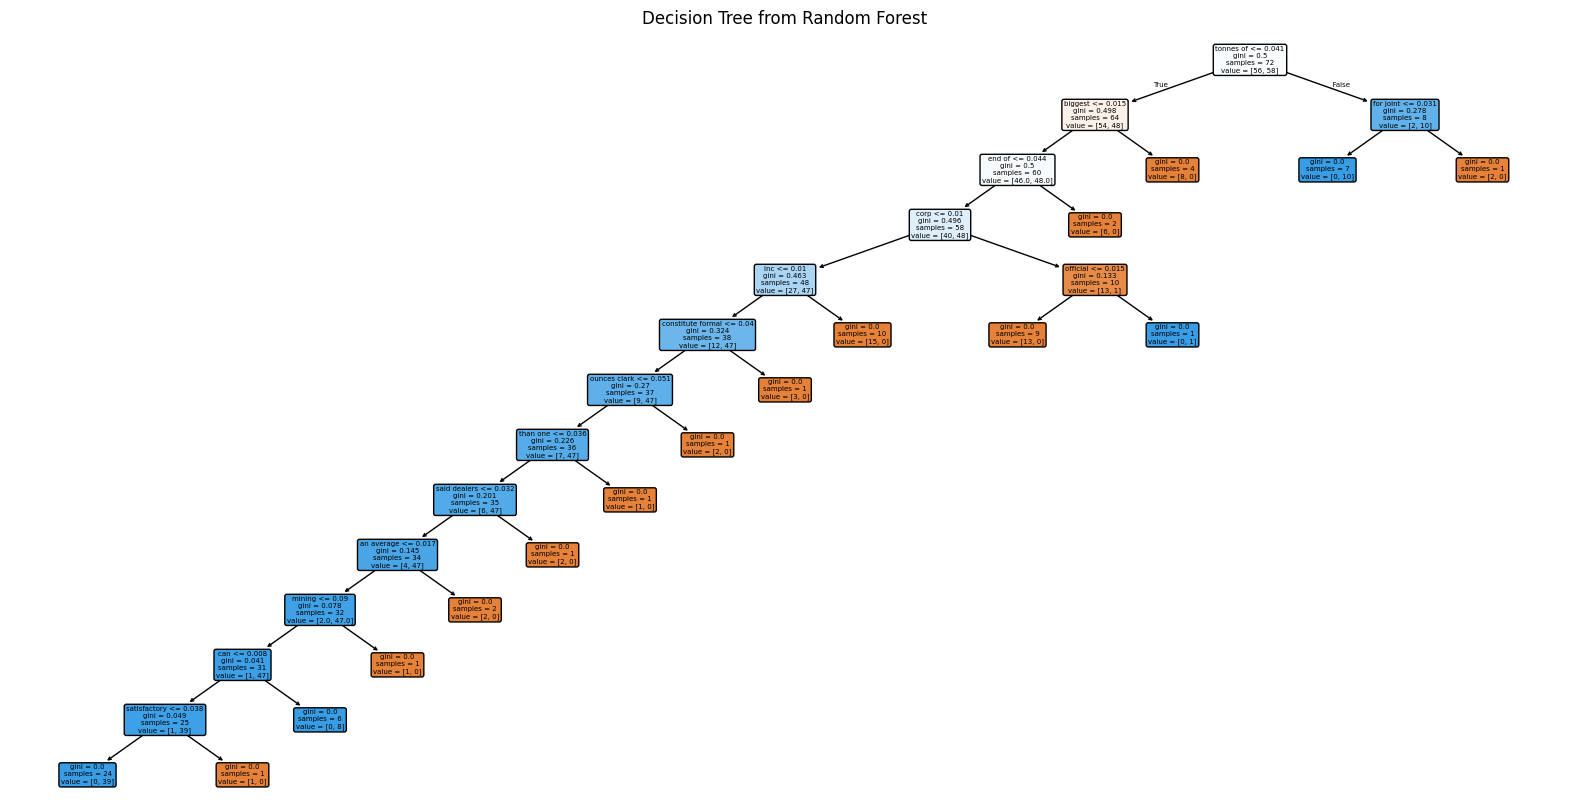

In [128]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_to_plot = rf_classifier.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot, feature_names=sa.get_feature_names_out(), filled=True, rounded=True, fontsize=5)
plt.title("Decision Tree from Random Forest")
plt.show()

In [129]:

# Predicting on the test set
class_test_predictions = clf.predict(X_test)
# Evaluation
print('Confusion Matrix DecisionTreeClassifier')
print(confusion_matrix(y_test, class_test_predictions))
print(classification_report(y_test, class_test_predictions))
print()
print('Accuracy :', '%.2f' % accuracy_score(y_test, class_test_predictions))

Confusion Matrix DecisionTreeClassifier
[[43  0]
 [ 0 43]]
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        43
           1       1.00      1.00      1.00        43

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86


Accuracy : 1.00


In [130]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

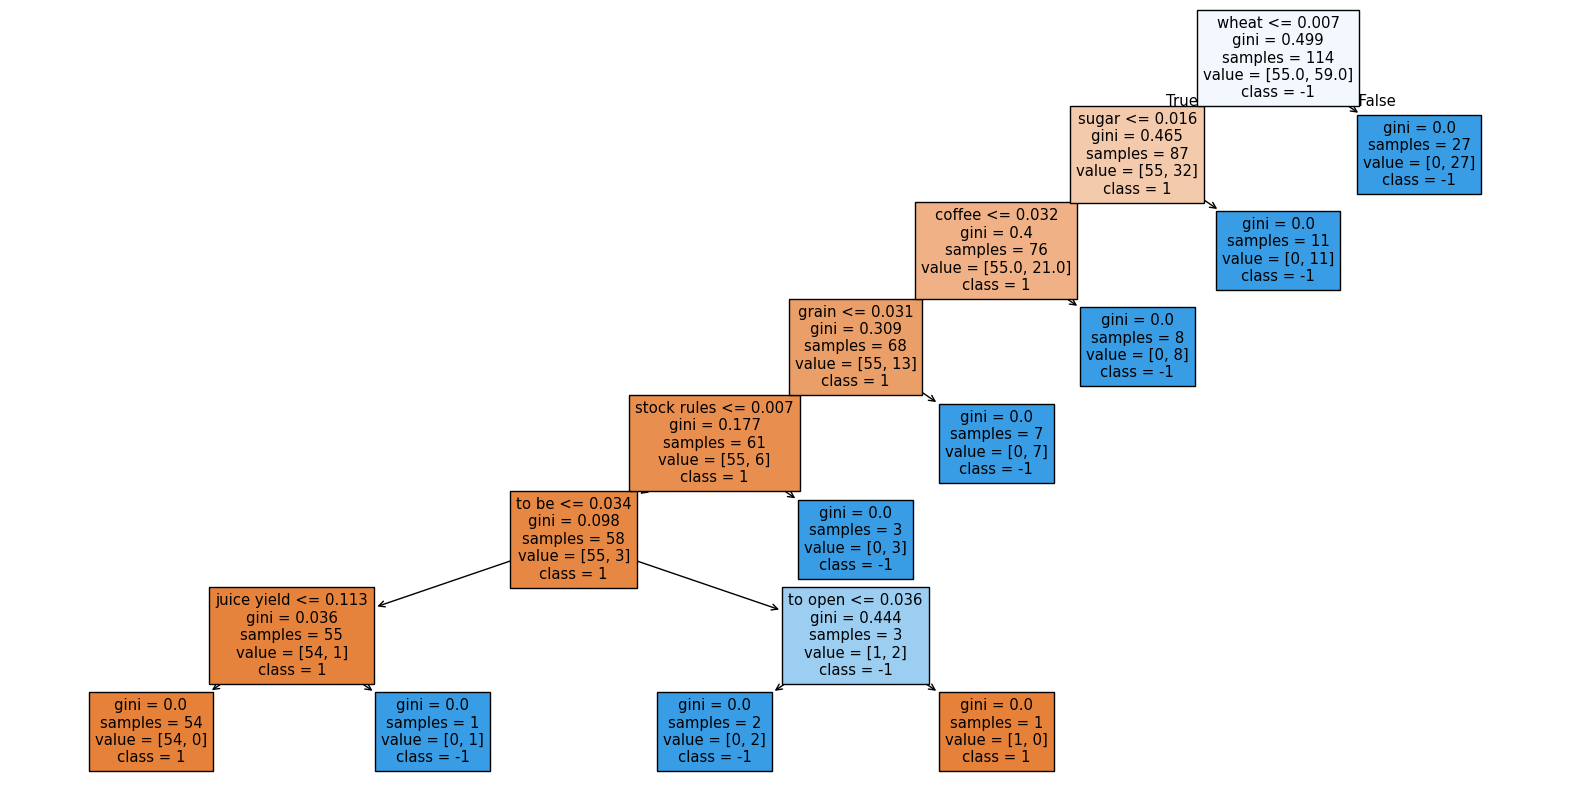

In [131]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
class_names =y.unique().astype(str)
# Visualizing the Decision Tree
plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=sa.get_feature_names_out(),class_names=class_names)
plt.show()

In [132]:
class_test_predictions = clf.predict(X_test)

print('Confusion Matrix DecisionTreeClassifier')
print(confusion_matrix(y_test, class_test_predictions))
print(classification_report(y_test, class_test_predictions))
print()
print('Accuracy :', '%.2f' % accuracy_score(y_test, class_test_predictions))

Confusion Matrix DecisionTreeClassifier
[[40  3]
 [16 27]]
              precision    recall  f1-score   support

          -1       0.71      0.93      0.81        43
           1       0.90      0.63      0.74        43

    accuracy                           0.78        86
   macro avg       0.81      0.78      0.77        86
weighted avg       0.81      0.78      0.77        86


Accuracy : 0.78


In [133]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf.fit(x, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

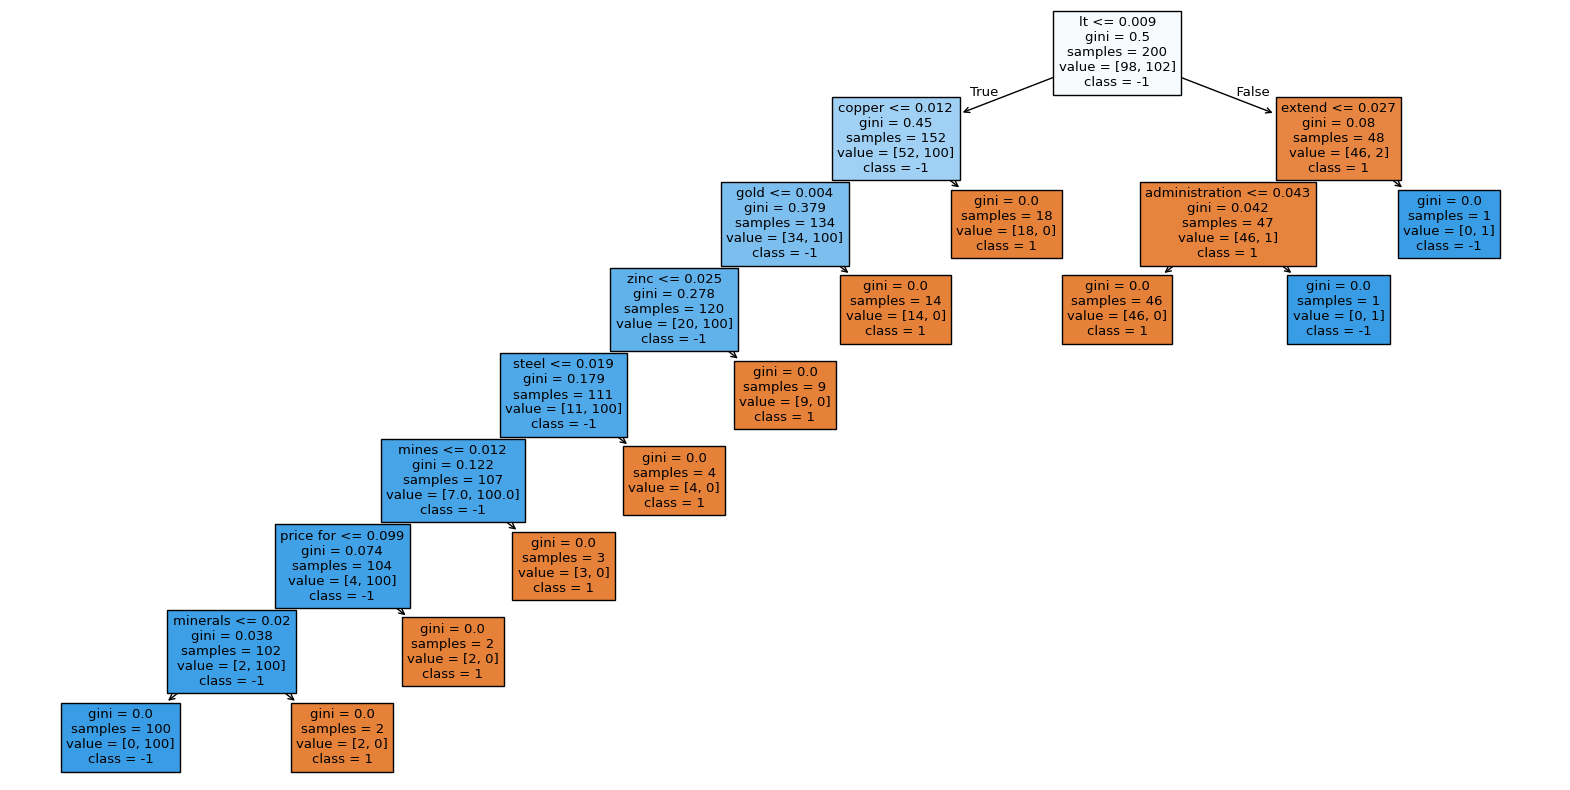

In [134]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
class_names = y.unique().astype(str)
plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=sa.get_feature_names_out(),class_names=class_names)
plt.show()

In [135]:
test = pd.read_csv("testsetwithoutlabels.txt", sep='\t',names=['HEADING','DATE','NEWS'])
test.head()

,HEADING,DATE,NEWS
0,USSR WHEAT BONUS OFFER SAID STILL UNDER DEBATE,"WASHINGTON, March 6 -",The Reagan administration continues to debat...
1,HAITIAN CANE PLANTERS PROTEST SUGAR MILL CLOSURE,"PORT-AU-PRINCE, April 13 -","About 2,000 sugar cane planters marched to P..."
2,U.S. URGES JAPAN TO OPEN FARM MARKET FURTHER,"TOKYO, April 17 -",U.S. Agriculture Secretary Richard Lyng has ...
3,NORANDA COPPER MINE SHUT DOWN AFTER FIRE,"TORONTO, April 2 -",Noranda Inc said production at its Murdochvi...
4,17 MISSING NORANDA MINERS FOUND ALIVE,"MURDOCHVILLE, Que., April 2-",Seventeen miners who were missing in a coppe...


In [136]:
test = pd.read_csv("testsetwithoutlabels.txt", sep='\t',names=['HEAD','DATE','NEWS'])
test.head()

,HEAD,DATE,NEWS
0,USSR WHEAT BONUS OFFER SAID STILL UNDER DEBATE,"WASHINGTON, March 6 -",The Reagan administration continues to debat...
1,HAITIAN CANE PLANTERS PROTEST SUGAR MILL CLOSURE,"PORT-AU-PRINCE, April 13 -","About 2,000 sugar cane planters marched to P..."
2,U.S. URGES JAPAN TO OPEN FARM MARKET FURTHER,"TOKYO, April 17 -",U.S. Agriculture Secretary Richard Lyng has ...
3,NORANDA COPPER MINE SHUT DOWN AFTER FIRE,"TORONTO, April 2 -",Noranda Inc said production at its Murdochvi...
4,17 MISSING NORANDA MINERS FOUND ALIVE,"MURDOCHVILLE, Que., April 2-",Seventeen miners who were missing in a coppe...


In [137]:
test['text'] = test['HEAD'] + " " + test['NEWS']
test['text'] = test['text'].str.lower()
test['text'] = test['text'].apply(c)

print(test['text'].head())

X_test = sa.transform(test['text'])
final_model_one = rf_classifier
final_model_two = clf

predictions = final_model_one.predict(X_test)
test['predicted_label'] = predictions
test.to_csv("output_d.txt", index=False)

print(test['text'].head())
print(test['predicted_label'].head())

predictions = final_model_two.predict(X_test)
test['predicted_label'] = predictions
test.to_csv("output_R.txt", index=False)

print(test['text'].head())
print(test['predicted_label'].head())

0    ussr wheat bonus offer said still under debate...
1    haitian cane planters protest sugar mill closu...
2    u s urges japan to open farm market further u ...
3    noranda copper mine shut down after fire noran...
4    missing noranda miners found alive seventeen m...
Name: text, dtype: str
0    ussr wheat bonus offer said still under debate...
1    haitian cane planters protest sugar mill closu...
2    u s urges japan to open farm market further u ...
3    noranda copper mine shut down after fire noran...
4    missing noranda miners found alive seventeen m...
Name: text, dtype: str
0    1
1    1
2    1
3   -1
4   -1
Name: predicted_label, dtype: int64
0    ussr wheat bonus offer said still under debate...
1    haitian cane planters protest sugar mill closu...
2    u s urges japan to open farm market further u ...
3    noranda copper mine shut down after fire noran...
4    missing noranda miners found alive seventeen m...
Name: text, dtype: str
0    1
1    1
2    1
3   -1
4   -1
